In [368]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [369]:
df = pd.read_csv("penguins_data.csv")

In [370]:
df

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,46.2,14.5,209.0,4800.0,Gentoo
1,37.3,20.5,199.0,3775.0,Adelie
2,39.6,20.7,191.0,3900.0,Adelie
3,44.1,19.7,196.0,4400.0,Adelie
4,41.5,18.3,195.0,4300.0,Adelie
...,...,...,...,...,...
116,47.5,14.0,212.0,4875.0,Gentoo
117,48.7,14.1,210.0,4450.0,Gentoo
118,36.2,17.3,187.0,3300.0,Adelie
119,37.2,18.1,178.0,3900.0,Adelie


In [371]:
print(df.shape)
df.info()
df.describe()

(121, 5)
<class 'pandas.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     120 non-null    float64
 1   bill_depth_mm      121 non-null    float64
 2   flipper_length_mm  121 non-null    float64
 3   body_mass_g        121 non-null    float64
 4   species            121 non-null    str    
dtypes: float64(4), str(1)
memory usage: 5.6 KB


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,120.000000,121.000000,121.000000,121.000000
mean,43.543333,16.948760,200.008264,4152.892562
std,5.502768,3.694097,14.039525,807.247058
min,34.100000,-17.000000,174.000000,2850.000000
25%,38.850000,15.700000,189.000000,3450.000000
50%,43.200000,17.300000,196.000000,4000.000000
75%,48.425000,18.900000,210.000000,4725.000000
max,55.100000,21.500000,231.000000,5850.000000


In [372]:
print(df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())

bill_length_mm       1
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
species              0
dtype: int64

Duplicated rows: 1


In [373]:
df["species"].unique()

<ArrowStringArray>
['Gentoo', 'Adelie', 'Chinstrap', 'ADELIE', '  Chinstrap', 'Aaadelie']
Length: 6, dtype: str

In [374]:
df["species"] = df["species"].astype(str).str.strip().str.lower()

species_corrections = {"aaadelie": "adelie"}
df["species"] = df["species"].replace(species_corrections)

In [375]:
df["species"].unique()

<ArrowStringArray>
['gentoo', 'adelie', 'chinstrap']
Length: 3, dtype: str

In [376]:
df = df.drop_duplicates().copy()

df.shape

(120, 5)

In [377]:
df.isnull().sum()

bill_length_mm       1
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
species              0
dtype: int64

In [378]:
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
# Replace non-positive values with NaN
for col in numeric_cols:
    df.loc[df[col] <= 0, col] = np.nan

In [379]:
df.isnull().sum()

bill_length_mm       1
bill_depth_mm        1
flipper_length_mm    0
body_mass_g          0
species              0
dtype: int64

In [380]:
df[df.isnull().any(axis=1)]

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
12,NaN,14.2,209.0,4600.0,gentoo
49,36.4,NaN,195.0,3325.0,adelie


In [381]:
for col in numeric_cols:
    df[col] = df.groupby("species")[col].transform(lambda x: x.fillna(x.median()))

In [382]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicated rows:", df.duplicated().sum())
print("\species counts:")
print(df["species"].value_counts())

df.describe()
df.to_csv('cleanedPenguinDataset.csv', index=False)

Missing values:
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
species              0
dtype: int64

Duplicated rows: 0
\species counts:
species
adelie       59
gentoo       41
chinstrap    20
Name: count, dtype: int64


In [384]:
# Applying equal-width binning
dfbin = df.copy()

dfbin["bill_length_mm_bin"] = pd.cut(
    dfbin["bill_length_mm"],
    bins=3,
    labels=["short", "medium", "long"]
)

dfbin[["bill_length_mm", "bill_length_mm_bin"]].head(10)

,bill_length_mm,bill_length_mm_bin
0,46.2,medium
1,37.3,short
2,39.6,short
3,44.1,medium
4,41.5,medium
5,43.8,medium
6,54.2,long
7,46.4,medium
8,50.4,long
9,40.6,short


In [385]:
dfbin["bill_length_mm_bin"].value_counts().sort_index()

bill_length_mm_bin
short     49
medium    41
long      30
Name: count, dtype: int64

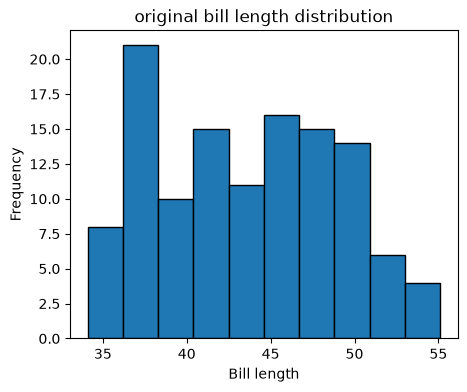

In [386]:
# Your code here
plt.figure(figsize=(5,4))
plt.hist(df["bill_length_mm"], bins=10, edgecolor="black")
plt.xlabel("Bill length")
plt.ylabel("Frequency")
plt.title("original bill length distribution")
plt.show()

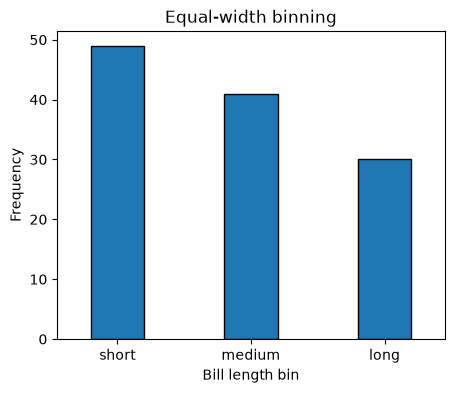

In [390]:
# Your code here
dfbin["bill_length_mm_bin"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(5, 4),
    edgecolor="black",
    width=0.4
)

plt.xticks(rotation=0)
plt.xlabel("Bill length bin")
plt.ylabel("Frequency")
plt.title("Equal-width binning")
plt.show()

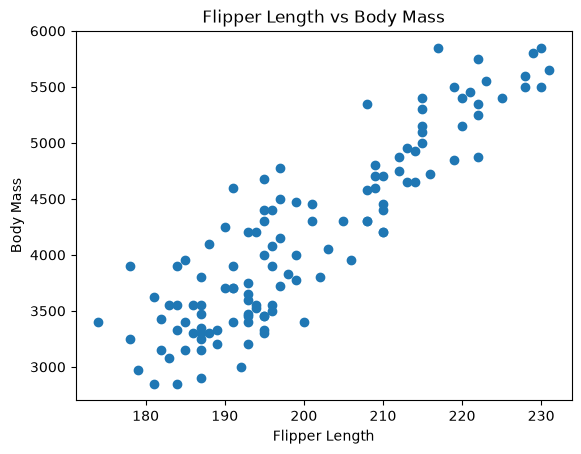

In [398]:
plt.scatter(df["flipper_length_mm"], df["body_mass_g"])

plt.xlabel("Flipper Length")
plt.ylabel("Body Mass")
plt.title("Flipper Length vs Body Mass")

plt.show()

In [ ]:
# Separate the inputs (X_penguin) and the label (y_penguin)
X_penguin = df[numeric_cols]
y_penguin = df["species"]

print(X_penguin.shape, y_penguin.shape)

In [ ]:
# Standardise the inputs with StandardScaler
penguin_scaler = StandardScaler()
penguin_scaler.fit(X_penguin)
X_penguin_scaled = penguin_scaler.transform(X_penguin)

In [ ]:
# Check the mean and standard deviation of each standardised column
X_penguin_scaled_df = pd.DataFrame(X_penguin_scaled, columns=numeric_cols)

X_penguin_scaled_df.agg(["mean", "std"]).round(2)

In [ ]:
# Fit PCA on the standardised data and transform it
penguin_pca = PCA(n_components=None)
penguin_pca.fit(X_penguin_scaled)
penguin_scores = penguin_pca.transform(X_penguin_scaled)

print("Explained-variance ratio:", penguin_pca.explained_variance_ratio_.round(4))
print("Shape of the scores:", penguin_scores.shape)

In [ ]:
print("Explained-variance ratio:", penguin_pca.explained_variance_ratio_.round(4))

In [ ]:
# Individual and cumulative contribution of each component
penguin_individual = penguin_pca.explained_variance_ratio_
penguin_cumulative = np.cumsum(penguin_individual)

penguin_contribution = pd.DataFrame({
    "component": ["PC1", "PC2", "PC3", "PC4"],
    "individual_contribution": penguin_individual,
    "cumulative_contribution": penguin_cumulative
})

penguin_contribution.round(4)

In [ ]:
# Loadings: rows = original features, columns = components
penguin_loadings = pd.DataFrame(
    penguin_pca.components_.T,
    index=numeric_cols,
    columns=["PC1", "PC2", "PC3", "PC4"]
)

penguin_loadings.round(3)

In [ ]:
# Bar chart of individual contributions with a cumulative line
component_numbers = np.arange(1, 5)

plt.figure(figsize=(6, 4))
plt.bar(component_numbers, penguin_individual * 100, label="Individual")
plt.plot(component_numbers, penguin_cumulative * 100, marker="o", color="darkorange", label="Cumulative")

plt.xticks(component_numbers)
plt.ylim(0, 105)
plt.xlabel("Principal component")
plt.ylabel("Explained variance (%)")
plt.title("PCA contribution for the cleaned penguin data")
plt.legend()
plt.show()

In [ ]:
# Keep three components and store the result in a DataFrame
penguin_pca3 = PCA(n_components=3)
penguin_scores_3 = penguin_pca3.fit_transform(X_penguin_scaled)

df_pca = pd.DataFrame(penguin_scores_3, columns=["PC1", "PC2", "PC3"])
df_pca["species"] = y_penguin.to_numpy()

print(df_pca.shape)
df_pca.head()

In [ ]:
# Save the three-component representation
df_pca.to_csv("penguinTransformedDataset.csv", index=False)

print("PCA result saved.")